Notebook para modelo de Red neuronal

In [42]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [43]:
# df = pd.read_csv("../../data/processed/.csv")
df = pd.read_csv("../../data/raw/dataset_practica_final.csv")

In [44]:
categorical_columns = ["hotel", "arrival_date_month", "meal", "country", "market_segment", "distribution_channel", "is_repeated_guest", "reserved_room_type", "assigned_room_type", "deposit_type", "customer_type"]
numerical_columns = ["lead_time", "arrival_date_year", "arrival_date_week_number", "arrival_date_day_of_month", "stays_in_weekend_nights", "stays_in_week_nights", "adults", "children", "babies", "is_repeated_guest", "previous_cancellations", "previous_bookings_not_canceled", "booking_changes", "agent", "days_in_waiting_list", "adr", "required_car_parking_spaces", "total_of_special_requests"]                                  

In [45]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_columns),
    ("cat", categorical_transformer, categorical_columns)
])

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [47]:
X = df.drop(columns=["is_canceled", "company", "reservation_status", "reservation_status_date"])
y = df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

In [48]:
X_train_preprocessed.shape

(95512, 253)

In [49]:
X_test_preprocessed.shape

(23878, 253)

In [50]:
neural_network_m1 = models.Sequential([
    layers.Input(shape=(X_train_preprocessed.shape[1],), name="i1"),
    layers.Dense(32, activation="relu", name="h1"),
    layers.Dense(16, activation="relu", name="h2"),
    layers.Dense(1, activation="sigmoid", name="o1")
])

neural_network_m1.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
neural_network_m1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 32)             │         8,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ o1 (Dense)                      │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,673 (33.88 KB)

 Trainable params: 8,673 (33.88 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = neural_network_m1.fit(X_train_preprocessed, y_train, batch_size=32, epochs=200, callbacks=[early_stopping], validation_split=.2)

Epoch 1/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 324us/step - accuracy: 0.8041 - loss: 0.4077 - val_accuracy: 0.8390 - val_loss: 0.3373
Epoch 2/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 297us/step - accuracy: 0.8473 - loss: 0.3229 - val_accuracy: 0.8525 - val_loss: 0.3185
Epoch 3/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 298us/step - accuracy: 0.8559 - loss: 0.3060 - val_accuracy: 0.8576 - val_loss: 0.3127
Epoch 4/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 296us/step - accuracy: 0.8593 - loss: 0.3012 - val_accuracy: 0.8579 - val_loss: 0.3074
Epoch 5/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 297us/step - accuracy: 0.8621 - loss: 0.2957 - val_accuracy: 0.8596 - val_loss: 0.3041
Epoch 6/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 298us/step - accuracy: 0.8674 - loss: 0.2863 - val_accuracy: 0.8573 - val_loss: 0.3046
Epoch 7/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 298us/step - accuracy: 0.8661 - loss: 0.2862 - val_accuracy: 0.8625 - val_loss: 0.2996
Epoch 8/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 297us/step - accuracy: 

In [52]:
loss, acc = neural_network_m1.evaluate(X_test_preprocessed, y_test)
print(f"Test Loss: {loss:.4f}, Test ACC: {acc:.4f}")

747/747 ━━━━━━━━━━━━━━━━━━━━ 0s 212us/step - accuracy: 0.8615 - loss: 0.2984
Test Loss: 0.2943, Test ACC: 0.8643


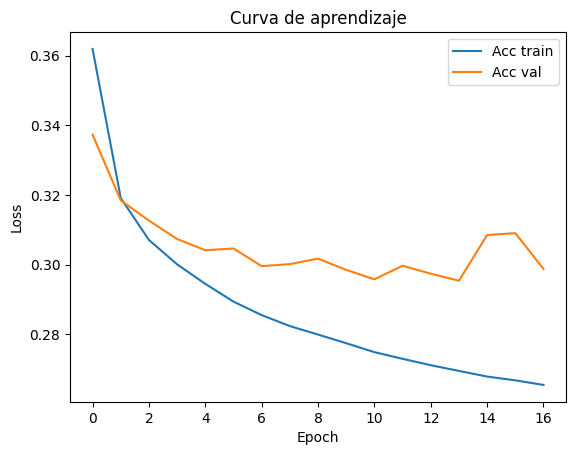

In [53]:
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de aprendizaje')
plt.legend()
plt.show()

In [54]:
y_prob = neural_network_m1.predict(X_test_preprocessed)
y_pred = (y_prob > 0.5).astype(int)

747/747 ━━━━━━━━━━━━━━━━━━━━ 0s 236us/step


In [61]:
y_pred = (y_prob > 0.4).astype(int)

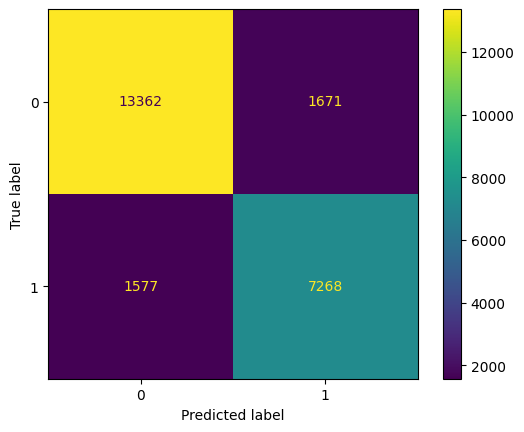

In [62]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [63]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89     15033
           1       0.81      0.82      0.82      8845

    accuracy                           0.86     23878
   macro avg       0.85      0.86      0.85     23878
weighted avg       0.86      0.86      0.86     23878



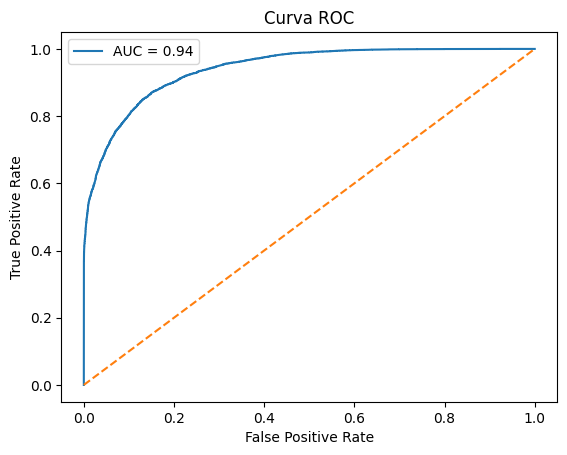

In [64]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

In [70]:
neural_network_m2 = models.Sequential([
    layers.Input(shape=(X_test_preprocessed.shape[1],), name="i1"),
    layers.Dense(16, activation="relu", name="h1"),
    layers.Dense(1, activation="sigmoid", name="o1"),
])

neural_network_m2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
neural_network_m2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 16)             │         4,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ o1 (Dense)                      │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,209 (16.44 KB)

 Trainable params: 4,209 (16.44 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
history = neural_network_m2.fit(X_train_preprocessed, y_train, batch_size=32, epochs=200, callbacks=[early_stopping], validation_split=.2)

Epoch 1/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 313us/step - accuracy: 0.7711 - loss: 0.4482 - val_accuracy: 0.8382 - val_loss: 0.3442
Epoch 2/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 287us/step - accuracy: 0.8451 - loss: 0.3301 - val_accuracy: 0.8429 - val_loss: 0.3322
Epoch 3/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 286us/step - accuracy: 0.8511 - loss: 0.3197 - val_accuracy: 0.8463 - val_loss: 0.3278
Epoch 4/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 285us/step - accuracy: 0.8569 - loss: 0.3079 - val_accuracy: 0.8489 - val_loss: 0.3206
Epoch 5/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 286us/step - accuracy: 0.8582 - loss: 0.3034 - val_accuracy: 0.8528 - val_loss: 0.3154
Epoch 6/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 286us/step - accuracy: 0.8603 - loss: 0.2996 - val_accuracy: 0.8544 - val_loss: 0.3126
Epoch 7/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 287us/step - accuracy: 0.8615 - loss: 0.2981 - val_accuracy: 0.8568 - val_loss: 0.3113
Epoch 8/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 287us/step - accuracy: 

In [72]:
loss, acc = neural_network_m2.evaluate(X_test_preprocessed, y_test)
print(f"Test Loss: {loss:.4f}, Test ACC: {acc:.4f}")

747/747 ━━━━━━━━━━━━━━━━━━━━ 0s 210us/step - accuracy: 0.8575 - loss: 0.3041
Test Loss: 0.3026, Test ACC: 0.8579


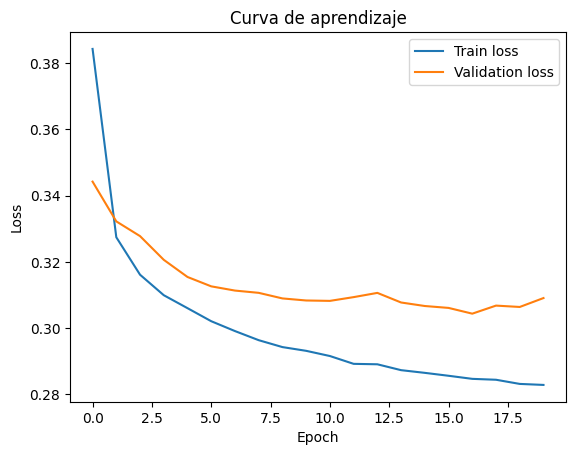

In [73]:
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de aprendizaje')
plt.legend()
plt.show()

In [74]:
y_prob = neural_network_m2.predict(X_test_preprocessed)
y_pred = (y_prob > 0.4).astype(int)

747/747 ━━━━━━━━━━━━━━━━━━━━ 0s 233us/step


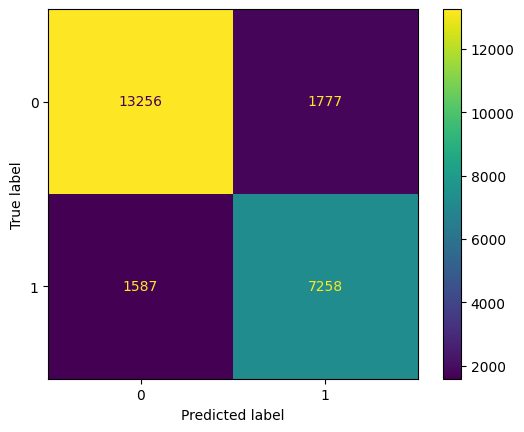

In [75]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [77]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.88      0.89     15033
           1       0.80      0.82      0.81      8845

    accuracy                           0.86     23878
   macro avg       0.85      0.85      0.85     23878
weighted avg       0.86      0.86      0.86     23878



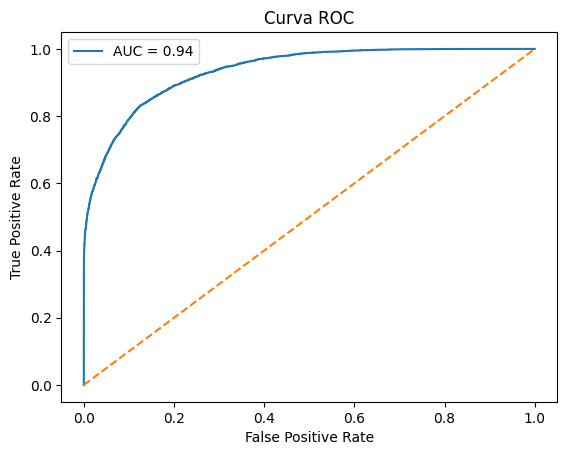

In [76]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

In [96]:
neural_network_m3 = models.Sequential([
    layers.Input(shape=(X_train_preprocessed.shape[1],), name="i1"),
    layers.Dense(16, activation="relu", name="h1"),
    layers.Dropout(0.1),
    layers.Dense(1, activation="sigmoid", name="o1")
])

neural_network_m3.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
neural_network_m3.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 16)             │         4,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ o1 (Dense)                      │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,081 (15.94 KB)

 Trainable params: 4,081 (15.94 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
history = neural_network_m3.fit(X_train_preprocessed, y_train, batch_size=32, epochs=200, callbacks=[early_stopping], validation_split=.2)

Epoch 1/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 307us/step - accuracy: 0.7836 - loss: 0.4439 - val_accuracy: 0.8261 - val_loss: 0.3559
Epoch 2/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 283us/step - accuracy: 0.8318 - loss: 0.3511 - val_accuracy: 0.8443 - val_loss: 0.3375
Epoch 3/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 282us/step - accuracy: 0.8438 - loss: 0.3307 - val_accuracy: 0.8487 - val_loss: 0.3266
Epoch 4/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 282us/step - accuracy: 0.8488 - loss: 0.3232 - val_accuracy: 0.8533 - val_loss: 0.3223
Epoch 5/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 282us/step - accuracy: 0.8514 - loss: 0.3185 - val_accuracy: 0.8552 - val_loss: 0.3176
Epoch 6/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 281us/step - accuracy: 0.8551 - loss: 0.3135 - val_accuracy: 0.8565 - val_loss: 0.3138
Epoch 7/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 282us/step - accuracy: 0.8572 - loss: 0.3076 - val_accuracy: 0.8576 - val_loss: 0.3112
Epoch 8/200
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 281us/step - accuracy: 

In [98]:
loss, acc = neural_network_m3.evaluate(X_test_preprocessed, y_test)
print(f"Test Loss: {loss:.4f}, Test ACC: {acc:.4f}")

747/747 ━━━━━━━━━━━━━━━━━━━━ 0s 226us/step - accuracy: 0.8622 - loss: 0.3039
Test Loss: 0.3004, Test ACC: 0.8628


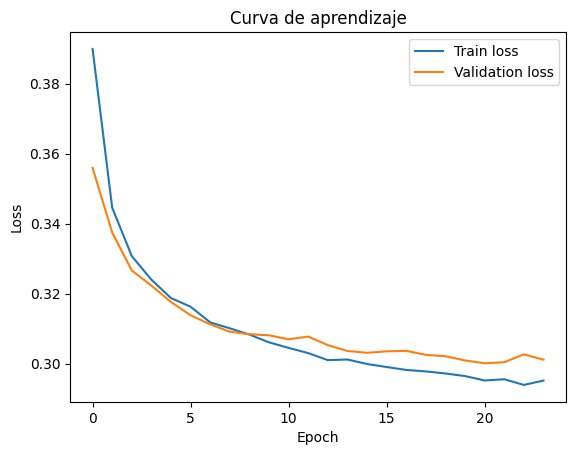

In [99]:
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de aprendizaje')
plt.legend()
plt.show()

In [100]:
y_prob = neural_network_m3.predict(X_test_preprocessed)
y_pred = (y_prob > 0.4).astype(int)

747/747 ━━━━━━━━━━━━━━━━━━━━ 0s 229us/step


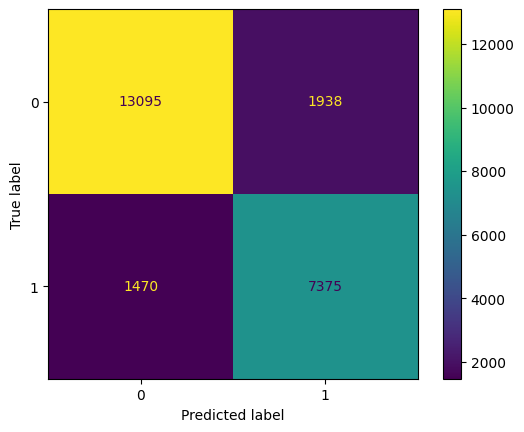

In [101]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [102]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88     15033
           1       0.79      0.83      0.81      8845

    accuracy                           0.86     23878
   macro avg       0.85      0.85      0.85     23878
weighted avg       0.86      0.86      0.86     23878



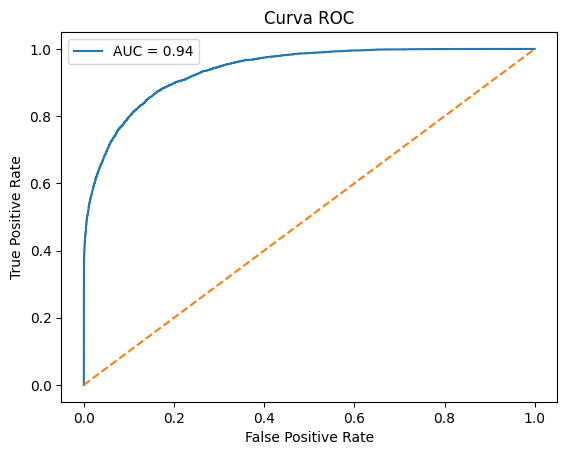

In [103]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()